# Phase 5 - Emotional Clustering, PCA and Similar Songs

notebook uses **unsupervised learning** to find natural groupings in the audio-feature data.

The phase has four main parts:

1. Using **K-Means** to discover audio/emotional clusters without genre or mood labels.
2. Using **PCA** to reduce the feature space to two dimensions for visualization.
3. Using **hierarchical clustering** on a representative sample to view how songs group together.
4. Building a **Nearest Neighbors** model for the future "similar songs" feature.

In [1]:
import os
import json
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sns.set_theme(style='whitegrid')

os.makedirs('models/metadata', exist_ok=True)
os.makedirs('reports/figures/05_clustering', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)
os.makedirs('reports/clustering', exist_ok=True)
os.makedirs('artifacts/dashboard', exist_ok=True)

print("Working folder:", os.getcwd())

Working folder: C:\dev\Moodwave\moodwave-ml


## 1. Load the Phase 2 processed data

Clustering needs one row per real track, so the main table here is `track_catalog`. Historical and genre data are also loaded so we can attach a useful popularity value to each track where available.

In [2]:
if os.path.exists('data/processed/track_catalog.parquet'):
    track_catalog = pd.read_parquet('data/processed/track_catalog.parquet')
    historical = pd.read_parquet('data/processed/historical_tracks.parquet')
    genre = pd.read_parquet('data/processed/genre_tracks.parquet')
else:
    track_catalog = pd.read_csv('data/processed/track_catalog.csv.gz')
    historical = pd.read_csv('data/processed/historical_tracks.csv.gz')
    genre = pd.read_csv('data/processed/genre_tracks.csv.gz')

print('Track catalog:', track_catalog.shape)
print('Historical:', historical.shape)
print('Genre:', genre.shape)

Track catalog: (115657, 24)
Historical: (2400, 28)
Genre: (113550, 27)


In [3]:
track_catalog.head()

,track_id,track_name,artist_name,album_name,explicit,danceability,energy,key,loudness,mode,...,valence,tempo,duration_ms,time_signature,genre_count,genres,primary_genre,in_genre_dataset,in_historical_dataset,in_country_dataset
0,0000vdREvCVMxbQTkS888c,Lolly,Rill,Lolly,True,0.910,0.374,8,-9.844,0,...,0.432,104.042,160725,4,1.0,german,german,True,False,False
1,000CC8EParg64OmTxVnZ0p,It's All Coming Back To Me Now (Glee Cast Vers...,Glee Cast,Glee Love Songs,False,0.269,0.516,0,-7.361,1,...,0.341,178.174,322933,4,1.0,club,club,True,False,False
2,000Iz0K615UepwSJ5z2RE5,Böxig Leise - Pig & Dan Remix,Paul Kalkbrenner;Pig&Dan,X,False,0.686,0.560,5,-13.264,0,...,0.108,119.997,515360,4,1.0,minimal-techno,minimal-techno,True,False,False
3,000RDCYioLteXcutOjeweY,Teeje Week,Jordan Sandhu,Teeje Week,False,0.679,0.770,0,-3.537,1,...,0.839,161.721,190203,4,1.0,hip-hop,hip-hop,True,False,False
4,000n6Lx4yqUAslF1x3JeFY,béke,"Azahriah, DESH, Young Fly, Lord Panamo, Copy Con",tripq,False,0.676,0.728,9,-7.661,0,...,0.938,174.089,315862,4,NaN,None,None,False,False,True


## 2. Select the clustering features

For clustering we use continuous audio characteristics. `key`, `mode` and `time_signature` are not included because treating those discrete values as normal numeric distances can be misleading.

In [4]:
cluster_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

cluster_data = track_catalog.dropna(subset=cluster_features).copy()

print('Tracks available for clustering:', len(cluster_data))
print(cluster_features)

Tracks available for clustering: 115657
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


### Add mood and popularity only for later cluster interpretation

These columns are **not used to train K-Means**. They are attached afterward so we can understand what each discovered cluster contains.

In [5]:
# Mood is still defined by the same valence-energy rule from Phase 2.
conditions = [
    (cluster_data['valence'] >= 0.50) & (cluster_data['energy'] >= 0.50),
    (cluster_data['valence'] >= 0.50) & (cluster_data['energy'] < 0.50),
    (cluster_data['valence'] < 0.50) & (cluster_data['energy'] >= 0.50),
    (cluster_data['valence'] < 0.50) & (cluster_data['energy'] < 0.50)
]

moods = ['Euphoric', 'Peaceful', 'Aggressive', 'Melancholic']
cluster_data['mood_label'] = np.select(conditions, moods, default='Unknown')

# Build one average popularity value per track from the available source datasets.
popularity_rows = pd.concat([
    historical[['track_id', 'popularity']],
    genre[['track_id', 'popularity']]
], ignore_index=True)

popularity_lookup = popularity_rows.groupby('track_id')['popularity'].mean()
cluster_data['popularity'] = cluster_data['track_id'].map(popularity_lookup)

cluster_data[['track_name', 'artist_name', 'mood_label', 'primary_genre', 'popularity']].head()

,track_name,artist_name,mood_label,primary_genre,popularity
0,Lolly,Rill,Melancholic,german,44.0
1,It's All Coming Back To Me Now (Glee Cast Vers...,Glee Cast,Aggressive,club,47.0
2,Böxig Leise - Pig & Dan Remix,Paul Kalkbrenner;Pig&Dan,Aggressive,minimal-techno,22.0
3,Teeje Week,Jordan Sandhu,Euphoric,hip-hop,62.0
4,béke,"Azahriah, DESH, Young Fly, Lord Panamo, Copy Con",Euphoric,None,NaN


## 3. Standardize the feature values

K-Means uses distance, so features measured on different scales must be standardized first.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[cluster_features])

print('Scaled feature matrix:', X_scaled.shape)

Scaled feature matrix: (115657, 10)


## 4. Compare different values of K

We test `K = 2` to `10` using both **inertia** and **silhouette score**.

Silhouette score is calculated on a reproducible sample of up to 5,000 tracks so the notebook stays practical on a normal laptop.

In [7]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

sample_size = min(5000, len(cluster_data))
rng = np.random.RandomState(42)
sample_positions = rng.choice(len(cluster_data), size=sample_size, replace=False)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(
            X_scaled[sample_positions],
            labels[sample_positions]
        )
    )

k_evaluation = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette_score': silhouette_scores
})

k_evaluation

,k,inertia,silhouette_score
0,2,937613.117015,0.254706
1,3,842780.043945,0.154730
2,4,775514.514108,0.159049
3,5,711390.258567,0.163922
4,6,658958.711304,0.162420
5,7,612365.678648,0.167214
6,8,581168.862065,0.170847
7,9,555215.692421,0.157089
8,10,534846.213347,0.152306


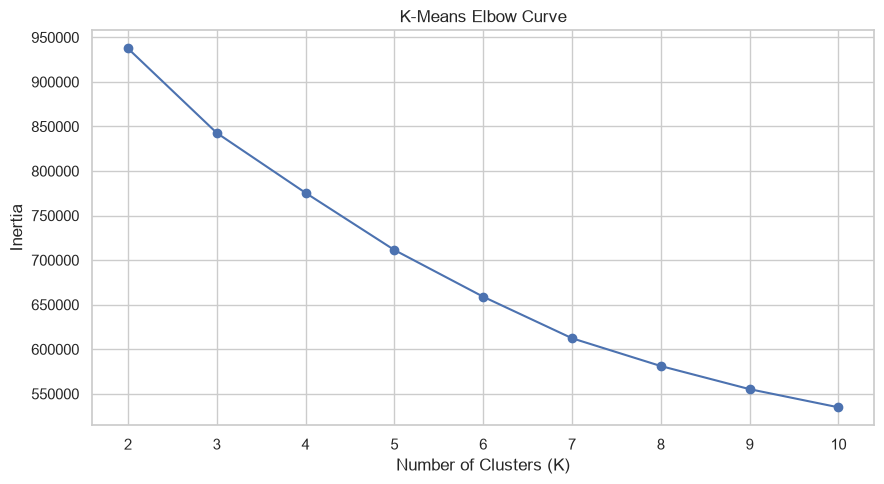

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(k_evaluation['k'], k_evaluation['inertia'], marker='o')
plt.title('K-Means Elbow Curve')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_evaluation['k'])
plt.tight_layout()
plt.savefig('reports/figures/05_clustering/elbow_curve.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/05_clustering/elbow_curve.svg', bbox_inches='tight')
plt.show()

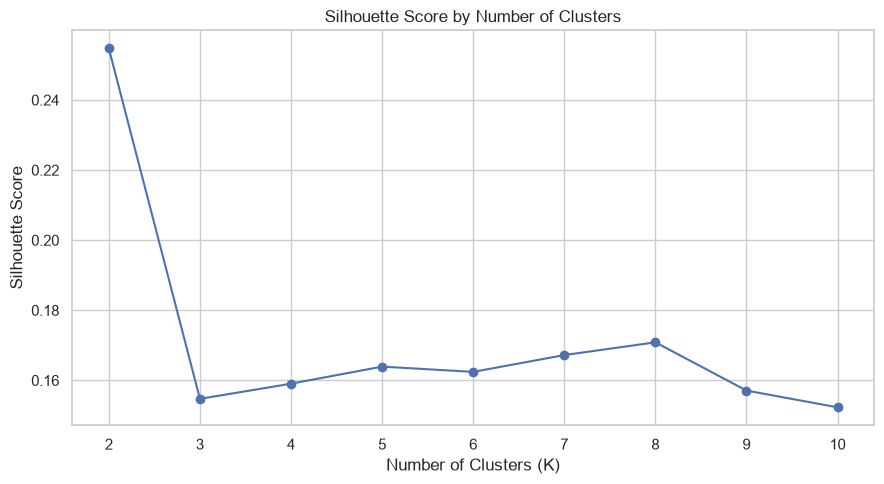

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(k_evaluation['k'], k_evaluation['silhouette_score'], marker='o')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_evaluation['k'])
plt.tight_layout()
plt.savefig('reports/figures/05_clustering/silhouette_scores.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/05_clustering/silhouette_scores.svg', bbox_inches='tight')
plt.show()

### Choosing the final K

`K=2` often receives the largest silhouette score because it creates two very broad groups. For Moodwave that split is too coarse for useful emotional exploration.

The inertia curve continues to improve substantially through the middle of the tested range. **K=5** gives a useful compromise: the clusters remain reasonably distinct, the sizes are practical, and the resulting profiles describe several clearly different types of songs rather than only a binary split.

This is an analytical choice supported by the metrics and the resulting profiles, not a claim that five is the only possible clustering of music.

In [10]:
final_k = 5

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_data['cluster_id'] = kmeans.fit_predict(X_scaled)

print(cluster_data['cluster_id'].value_counts().sort_index())

cluster_id
0    46636
1    24123
2    29013
3     7598
4     8287
Name: count, dtype: int64


## 5. Profile the discovered clusters

We now inspect the feature means, mood composition, common genres and average popularity **after** clustering.

In [11]:
cluster_feature_means = (
    cluster_data
    .groupby('cluster_id')[cluster_features]
    .mean()
)

cluster_counts = cluster_data.groupby('cluster_id').size().rename('track_count')

cluster_moods = pd.crosstab(
    cluster_data['cluster_id'],
    cluster_data['mood_label'],
    normalize='index'
) * 100

cluster_moods = cluster_moods.rename(columns={
    'Euphoric': 'pct_euphoric',
    'Peaceful': 'pct_peaceful',
    'Aggressive': 'pct_aggressive',
    'Melancholic': 'pct_melancholic'
})

common_genres = (
    cluster_data
    .dropna(subset=['primary_genre'])
    .groupby('cluster_id')['primary_genre']
    .apply(lambda x: ', '.join(x.value_counts().head(5).index))
    .rename('common_genres')
)

average_popularity = (
    cluster_data
    .groupby('cluster_id')['popularity']
    .mean()
    .rename('mean_popularity')
)

cluster_profiles = pd.concat([
    cluster_counts,
    cluster_feature_means,
    average_popularity,
    common_genres,
    cluster_moods
], axis=1).reset_index()

cluster_profiles.round(3)

,cluster_id,track_count,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,mean_popularity,common_genres,pct_aggressive,pct_euphoric,pct_melancholic,pct_peaceful
0,0,46636,0.709,0.720,-6.326,0.111,0.202,0.031,0.164,0.669,120.884,199542.963,35.435,"dancehall, kids, salsa, forro, dance",18.243,74.786,1.840,5.131
1,1,24123,0.545,0.397,-10.310,0.061,0.660,0.044,0.159,0.402,113.966,211096.856,33.998,"tango, honky-tonk, cantopop, romance, acoustic",16.428,8.544,53.410,21.618
2,2,29013,0.497,0.797,-6.226,0.078,0.068,0.251,0.190,0.326,135.940,261868.120,33.190,"black-metal, grindcore, death-metal, drum-and-...",77.589,18.033,4.005,0.372
3,3,7598,0.367,0.195,-20.637,0.053,0.816,0.783,0.163,0.193,104.106,220014.895,28.708,"sleep, new-age, ambient, classical, iranian",4.764,0.474,86.891,7.870
4,4,8287,0.543,0.745,-7.438,0.203,0.341,0.059,0.723,0.505,121.171,227755.951,33.842,"comedy, pagode, sertanejo, samba, mpb",40.811,47.749,6.951,4.489


### Create short data-driven descriptions

The descriptions below are based on the three strongest standardized centroid characteristics for each cluster. This keeps the names tied to the data instead of inventing personalities beforehand.

In [12]:
centroid_z = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
)

pretty_names = {
    'danceability': 'danceability',
    'energy': 'energy',
    'loudness': 'loudness',
    'speechiness': 'speechiness',
    'acousticness': 'acousticness',
    'instrumentalness': 'instrumentalness',
    'liveness': 'liveness',
    'valence': 'valence',
    'tempo': 'tempo',
    'duration_ms': 'duration'
}

descriptions = []

for cluster_id in range(final_k):
    row = centroid_z.loc[cluster_id]
    strongest_features = row.abs().sort_values(ascending=False).head(3).index

    parts = []
    for feature in strongest_features:
        level = 'high' if row[feature] > 0 else 'low'
        parts.append(level + ' ' + pretty_names[feature])

    descriptions.append(', '.join(parts))

cluster_profiles['description'] = descriptions

cluster_profiles[
    ['cluster_id', 'track_count', 'description', 'common_genres', 'mean_popularity']
]

,cluster_id,track_count,description,common_genres,mean_popularity
0,0,46636,"high valence, high danceability, high loudness","dancehall, kids, salsa, forro, dance",35.435024
1,1,24123,"high acousticness, low energy, low loudness","tango, honky-tonk, cantopop, romance, acoustic",33.998130
2,2,29013,"low acousticness, high energy, low valence","black-metal, grindcore, death-metal, drum-and-...",33.189808
3,3,7598,"low loudness, high instrumentalness, low energy","sleep, new-age, ambient, classical, iranian",28.707796
4,4,8287,"high liveness, high speechiness, high energy","comedy, pagode, sertanejo, samba, mpb",33.841965


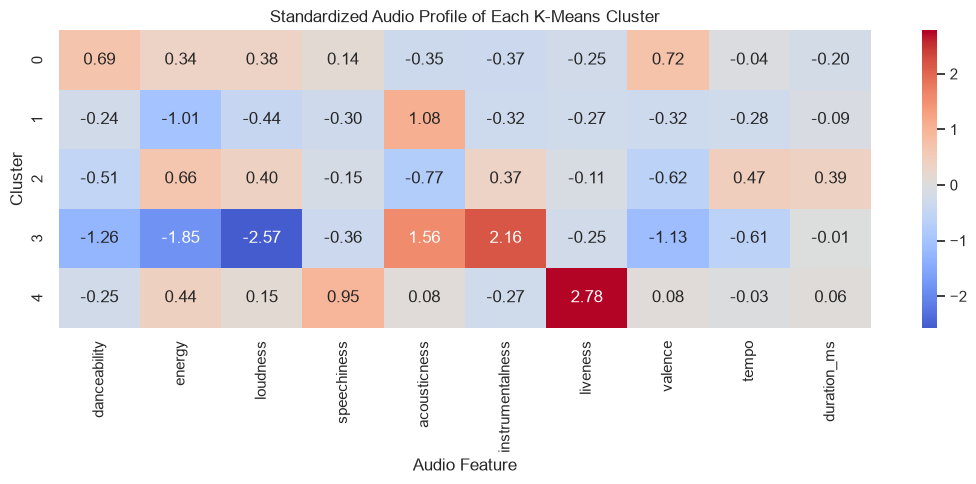

In [13]:
plt.figure(figsize=(11, 5))
sns.heatmap(
    centroid_z,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)
plt.title('Standardized Audio Profile of Each K-Means Cluster')
plt.xlabel('Audio Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('reports/figures/05_clustering/cluster_profile_heatmap.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/05_clustering/cluster_profile_heatmap.svg', bbox_inches='tight')
plt.show()

## 6. Representative tracks near each centroid

A representative track is one whose standardized audio profile is close to the center of its cluster.

In [14]:
distance_to_centroids = kmeans.transform(X_scaled)
representative_rows = []

for cluster_id in range(final_k):
    positions = np.where(cluster_data['cluster_id'].to_numpy() == cluster_id)[0]
    distances = distance_to_centroids[positions, cluster_id]
    closest_positions = positions[np.argsort(distances)[:5]]

    for position in closest_positions:
        row = cluster_data.iloc[position]
        representative_rows.append({
            'cluster_id': cluster_id,
            'track_id': row['track_id'],
            'track_name': row['track_name'],
            'artist_name': row['artist_name'],
            'primary_genre': row['primary_genre'],
            'mood_label': row['mood_label'],
            'distance_to_centroid': distance_to_centroids[position, cluster_id]
        })

representative_tracks = pd.DataFrame(representative_rows)
representative_tracks

,cluster_id,track_id,track_name,artist_name,primary_genre,mood_label,distance_to_centroid
0,0,70sKIAQgaVN2zWEEyOpyMZ,All Night (BTS World Original Soundtrack) [Pt. 3],BTS;Juice WRLD,k-pop,Euphoric,0.501185
1,0,4Tyh4Hjzmfuk8FrO8HNlWI,One Touch,Jess Glynne;Jax Jones,house,Euphoric,0.518314
2,0,4CrvuZnTyzReLCcXRMETLK,Yo Quiero Vivir,Manuel Carrasco,latin,Euphoric,0.521387
3,0,7HRfX5It3lx1E02wTRR0RX,MERCI,SDM,None,Euphoric,0.548043
4,0,58rVY9wmIYBOzdLXygVs6i,Mood,KeBlack,None,Euphoric,0.572240
5,1,6REc8idTpdDdMlMIcnER2F,That Heart Belongs To Me,George Jones,honky-tonk,Melancholic,0.533684
6,1,7n8ORc71tQ8NXkWfhg898Z,Ride Home,Alif;Noor Mohammad,folk,Melancholic,0.587585
7,1,4Wy375MMykH82pUm8EN3iE,Better Now,Oh Wonder,electro,Peaceful,0.593789
8,1,4hL6Jr0nOm5erNhCv7FpCT,Pé no Mar,Dillaz,None,Melancholic,0.645916
9,1,39fD0qvjgk8RarJnoBiDTx,Lovesick,Laufey,None,Melancholic,0.651397


## 7. PCA visualization

PCA reduces the ten standardized audio features to two components so the clusters can be displayed on a 2D chart. PCA is used here for visualization; it does not prove that the original ten-dimensional clusters are perfectly separated.

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_data['pca_1'] = X_pca[:, 0]
cluster_data['pca_2'] = X_pca[:, 1]

print('PC1 explained variance:', round(pca.explained_variance_ratio_[0] * 100, 2), '%')
print('PC2 explained variance:', round(pca.explained_variance_ratio_[1] * 100, 2), '%')
print('Total shown in 2D:', round(pca.explained_variance_ratio_.sum() * 100, 2), '%')

PC1 explained variance: 28.68 %
PC2 explained variance: 15.22 %
Total shown in 2D: 43.9 %


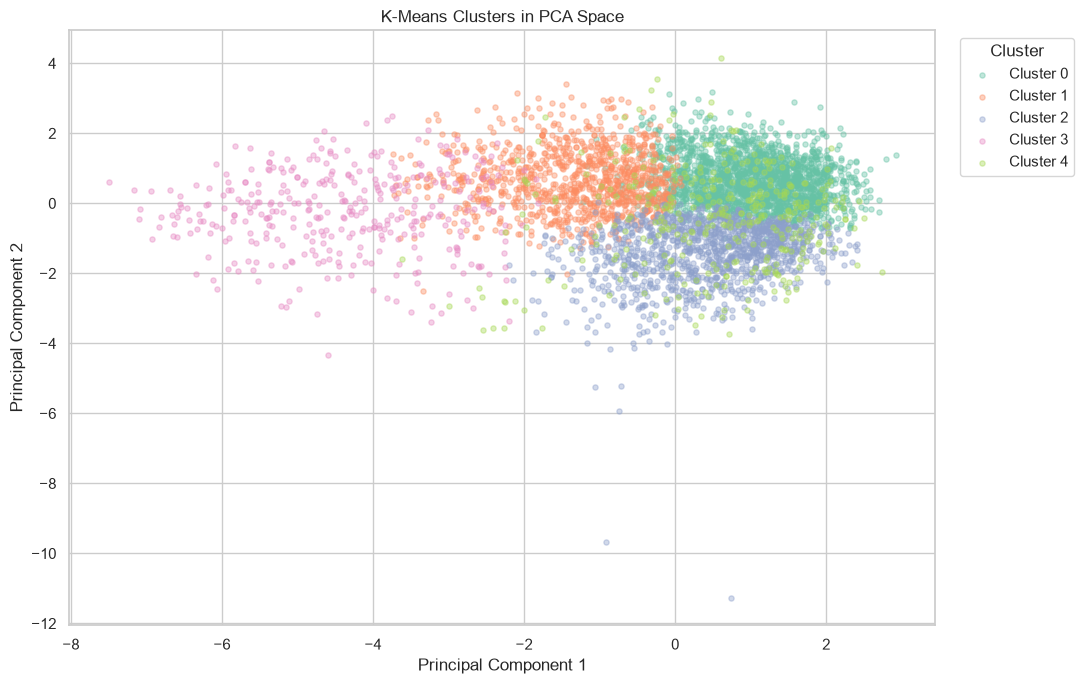

In [16]:
plot_sample = cluster_data.sample(
    n=min(5000, len(cluster_data)),
    random_state=42
)

cluster_colors = plt.get_cmap('Set2').colors

plt.figure(figsize=(11, 7))

for cluster_id in sorted(plot_sample['cluster_id'].unique()):
    subset = plot_sample[plot_sample['cluster_id'] == cluster_id]
    plt.scatter(
        subset['pca_1'],
        subset['pca_2'],
        s=14,
        alpha=0.40,
        label='Cluster ' + str(cluster_id),
        color=cluster_colors[cluster_id]
    )

plt.title('K-Means Clusters in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('reports/figures/05_clustering/pca_cluster_map.png', dpi=180, bbox_inches='tight')
plt.show()


## 8. Hierarchical clustering

Running hierarchical clustering on every track would be slow and the dendrogram would be unreadable. We therefore use a reproducible sample of 300 tracks and Ward linkage.

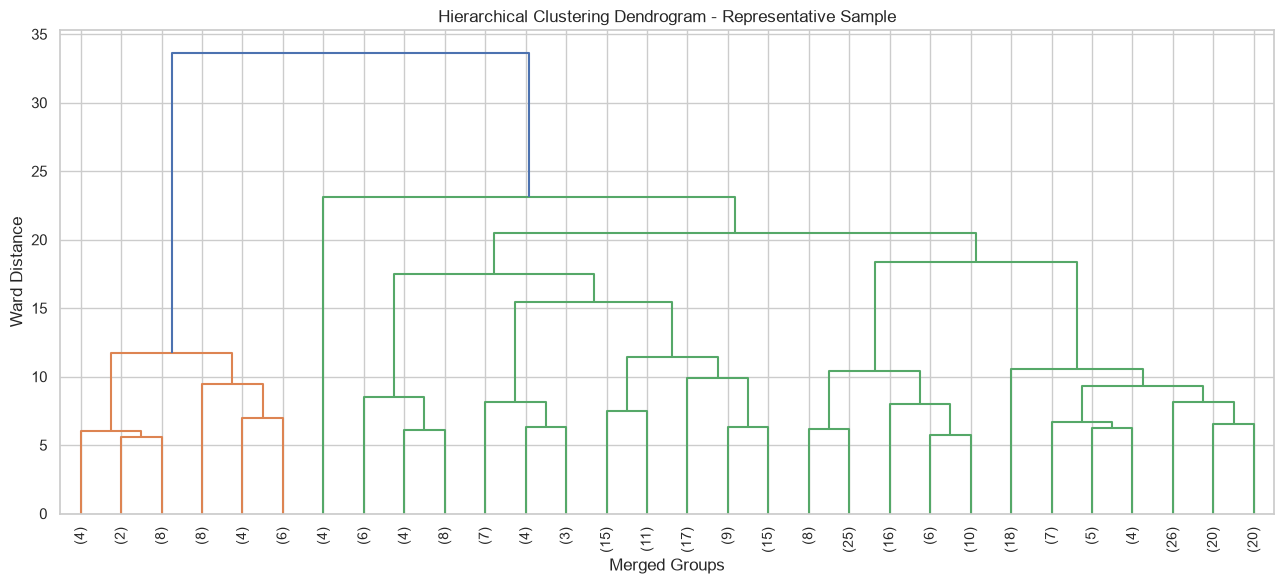

In [17]:
hierarchical_sample = cluster_data.sample(
    n=min(300, len(cluster_data)),
    random_state=42
)

hierarchical_scaled = scaler.transform(
    hierarchical_sample[cluster_features]
)

linkage_matrix = linkage(
    hierarchical_scaled,
    method='ward'
)

plt.figure(figsize=(13, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90
)
plt.title('Hierarchical Clustering Dendrogram - Representative Sample')
plt.xlabel('Merged Groups')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('reports/figures/05_clustering/dendrogram.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/05_clustering/dendrogram.svg', bbox_inches='tight')
plt.show()

## 9. Similar-song model with Nearest Neighbors

The future dashboard should be able to return real tracks with the closest audio profile to a given song or user-entered feature set. Nearest Neighbors is fitted on the same standardized feature space.

In [18]:
similarity_model = NearestNeighbors(
    metric='euclidean'
)

similarity_model.fit(X_scaled)

# Use Mr. Brightside when available so the example is easy to recognize.
bright_side = cluster_data[
    cluster_data['track_name'].astype(str).str.lower() == 'mr. brightside'
]

if len(bright_side) > 0:
    query_index = cluster_data.index.get_loc(bright_side.index[0])
else:
    query_index = 0

query_track = cluster_data.iloc[query_index]

# Ask for extra candidates because datasets can contain different Spotify IDs
# for the same recording. We keep five unique title + artist results.
distances, neighbor_positions = similarity_model.kneighbors(
    X_scaled[query_index].reshape(1, -1),
    n_neighbors=min(30, len(cluster_data))
)

query_title = str(query_track['track_name']).strip().lower()
query_artist = str(query_track['artist_name']).strip().lower()

similar_rows = []
seen_songs = set()

for position, distance in zip(neighbor_positions[0], distances[0]):
    row = cluster_data.iloc[position]
    title_key = str(row['track_name']).strip().lower()
    artist_key = str(row['artist_name']).strip().lower()
    song_key = (title_key, artist_key)

    # Skip the query song and duplicate versions of the same title/artist.
    if song_key == (query_title, query_artist):
        continue

    if song_key in seen_songs:
        continue

    seen_songs.add(song_key)

    similar_rows.append({
        'track_id': row['track_id'],
        'track_name': row['track_name'],
        'artist_name': row['artist_name'],
        'primary_genre': row['primary_genre'],
        'mood_label': row['mood_label'],
        'distance': distance
    })

    if len(similar_rows) == 5:
        break

similar_songs_example = pd.DataFrame(similar_rows)

print('Query track:', query_track['track_name'], '-', query_track['artist_name'])
similar_songs_example


Query track: Mr. Brightside - The Killers


,track_id,track_name,artist_name,primary_genre,mood_label,distance
0,54otdw8MmYNz2ewGHzmaTP,FEEL NOTHING - RESET,The Plot In You,metal,Aggressive,0.343821
1,536bkD2pabwDI6kHCzHv5T,Hollow,Breaking Benjamin,grunge,Aggressive,0.407666
2,5DLOpXvShlphkFSlAIwdDv,Leisure,Israeli Chicks,garage,Aggressive,0.411922
3,1YsAj4ybnMC11VoTg7k6s5,Back Round,Wolfmother,alt-rock,Aggressive,0.414693
4,6GTsPmY05JgqgMSgsfwMqN,Keepsake,Balance And Composure,grunge,Aggressive,0.458653


## 10. Save Phase 5 models and artifacts

In [19]:
# Save the scaler together with each distance-based model so later code uses the same preprocessing.
kmeans_bundle = {
    'features': cluster_features,
    'scaler': scaler,
    'model': kmeans
}

pca_bundle = {
    'features': cluster_features,
    'scaler': scaler,
    'model': pca
}

similarity_bundle = {
    'features': cluster_features,
    'scaler': scaler,
    'model': similarity_model
}

joblib.dump(kmeans_bundle, 'models/emotion_kmeans.joblib', compress=3)
joblib.dump(pca_bundle, 'models/emotion_pca.joblib', compress=3)
joblib.dump(similarity_bundle, 'models/similar_songs_nn.joblib', compress=3)

print('Phase 5 model files saved.')

Phase 5 model files saved.


In [20]:
# Machine-readable model metadata.
k5_row = k_evaluation[k_evaluation['k'] == final_k].iloc[0]

kmeans_metadata = {
    'model_name': 'emotion_kmeans',
    'model_version': '1.0.0',
    'trained_at': datetime.now().isoformat(timespec='seconds'),
    'features': cluster_features,
    'training_rows': int(len(cluster_data)),
    'n_clusters': int(final_k),
    'random_state': 42,
    'metrics': {
        'inertia': float(k5_row['inertia']),
        'silhouette_score_sample': float(k5_row['silhouette_score']),
        'silhouette_sample_rows': int(sample_size)
    },
    'sklearn_version': sklearn.__version__
}

pca_metadata = {
    'model_name': 'emotion_pca',
    'model_version': '1.0.0',
    'trained_at': datetime.now().isoformat(timespec='seconds'),
    'features': cluster_features,
    'training_rows': int(len(cluster_data)),
    'n_components': 2,
    'explained_variance_ratio': [float(x) for x in pca.explained_variance_ratio_],
    'explained_variance_total': float(pca.explained_variance_ratio_.sum()),
    'sklearn_version': sklearn.__version__
}

similarity_metadata = {
    'model_name': 'similar_songs_nn',
    'model_version': '1.0.0',
    'trained_at': datetime.now().isoformat(timespec='seconds'),
    'features': cluster_features,
    'training_rows': int(len(cluster_data)),
    'metric': 'euclidean',
    'default_neighbors': 5,
    'sklearn_version': sklearn.__version__
}

with open('models/metadata/emotion_kmeans.json', 'w') as f:
    json.dump(kmeans_metadata, f, indent=2)

with open('models/metadata/emotion_pca.json', 'w') as f:
    json.dump(pca_metadata, f, indent=2)

with open('models/metadata/similar_songs_nn.json', 'w') as f:
    json.dump(similarity_metadata, f, indent=2)

print('Phase 5 metadata saved.')

Phase 5 metadata saved.


In [21]:
# Full PCA/cluster table for the future dashboard.
cluster_points = cluster_data[[
    'track_id', 'track_name', 'artist_name', 'album_name',
    'primary_genre', 'genres', 'mood_label', 'popularity',
    'pca_1', 'pca_2', 'cluster_id'
]].copy()

# The similarity catalog must keep exactly the same row order used to fit Nearest Neighbors.
similarity_catalog = cluster_data[[
    'track_id', 'track_name', 'artist_name', 'album_name',
    'primary_genre', 'genres', 'mood_label'
]].copy().reset_index(drop=True)

cluster_points.to_csv(
    'artifacts/dashboard/cluster_points.csv.gz',
    index=False,
    compression='gzip'
)

similarity_catalog.to_csv(
    'artifacts/dashboard/similarity_catalog.csv.gz',
    index=False,
    compression='gzip'
)

# Parquet is the preferred dashboard format when PyArrow is installed.
try:
    cluster_points.to_parquet(
        'artifacts/dashboard/cluster_points.parquet',
        index=False
    )
    similarity_catalog.to_parquet(
        'artifacts/dashboard/similarity_catalog.parquet',
        index=False
    )
    print('Parquet dashboard artifacts saved.')
except ImportError:
    print('PyArrow is not installed here, so CSV.GZ dashboard copies were saved instead.')

cluster_profiles.to_csv('reports/tables/cluster_profiles.csv', index=False)
representative_tracks.to_csv('reports/tables/cluster_representative_tracks.csv', index=False)
k_evaluation.to_csv('reports/tables/kmeans_evaluation.csv', index=False)
similar_songs_example.to_csv('reports/tables/similar_songs_example.csv', index=False)

cluster_profiles.to_json(
    'artifacts/dashboard/cluster_profiles.json',
    orient='records',
    indent=2
)

print('Phase 5 tables and dashboard artifacts saved.')

Parquet dashboard artifacts saved.
Phase 5 tables and dashboard artifacts saved.


## 11. Reload the saved models and run quick smoke checks

In [22]:
loaded_kmeans = joblib.load('models/emotion_kmeans.joblib')
loaded_pca = joblib.load('models/emotion_pca.joblib')
loaded_nn = joblib.load('models/similar_songs_nn.joblib')

one_track = cluster_data.iloc[[0]][cluster_features]
one_scaled = loaded_kmeans['scaler'].transform(one_track)

print('Cluster prediction:', loaded_kmeans['model'].predict(one_scaled)[0])
print('PCA coordinates:', loaded_pca['model'].transform(loaded_pca['scaler'].transform(one_track))[0])
print('Nearest-neighbor indices:', loaded_nn['model'].kneighbors(
    loaded_nn['scaler'].transform(one_track),
    n_neighbors=5,
    return_distance=False
)[0])

Cluster prediction: 0
PCA coordinates: [0.16424561 1.61267908]
Nearest-neighbor indices: [     0  37056 113855 110333  96074]
